# 03_attribute_taxonomy.ipynb
## Data Preprocessing 2: Analyze and Simplify "categories" and "attributes" (dataset_business)

## 1. categories

Extract all unique categories from pa_filtered_dining_businesses.json

In [1]:
import json
import os

# Set base directory and file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_filtered_dining_businesses.json")
output_path = os.path.join(BASE_DIR, "output_categories", "pa_unique_categories.json")

# Ensure the output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Load filtered dining businesses
with open(input_path, 'r', encoding='utf-8') as f:
    businesses = json.load(f)

# Extract unique categories
unique_categories = set()

for business in businesses:
    categories = business.get("categories", "")
    if categories:
        unique_categories.update(map(str.strip, categories.split(',')))

# Convert to sorted list
unique_categories = sorted(unique_categories)

# Save unique categories to file
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(unique_categories, f, indent=2, ensure_ascii=False)

# Print results
print(f"Total unique categories extracted: {len(unique_categories)}")
print(f"Extracted categories saved to: {output_path}")

Total unique categories extracted: 484
Extracted categories saved to: d:\Programming\LLM_RS\output_categories\pa_unique_categories.json


Since there are 484 categories, using a one-hot encoding or multi-hot vector approach will result in very high-dimensional sparse vectors, making computations inefficient.

1. Remove: irrelevent categories & overly broad terms
2. Count occurrences of categories and sort them

In [ ]:
import json
import os
from collections import Counter

# Set base directory and file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_filtered_dining_businesses.json")
output_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories.json")
freq_output_path = os.path.join(BASE_DIR, "output_categories", "pa_category_frequencies.json")

# Ensure output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Load business data
with open(input_path, 'r', encoding='utf-8') as f:
    businesses = json.load(f)

# Initialize category counter
category_counter = Counter()

# Process each business entry
for business in businesses:
    if "categories" in business and business["categories"]:
        # Split categories by comma and count each
        categories = [c.strip() for c in business["categories"].split(",")]
        category_counter.update(categories)

# Define categories to remove (Non-food-related)
irrelevant_categories = {
    "Accessories", "Accountants", "Active Life", "Acupuncture", "Adult", "Adult Education", "Adult Entertainment",
    "Airlines", "Airport Lounges", "Airports", "Amusement Parks", "Antiques", "Apartments", "Appliances",
    "Appliances & Repair", "Arcades", "Art Classes", "Art Galleries", "Art Museums", "Art Schools", "Arts & Crafts",
    "Arts & Entertainment", "Attraction Farms", "Auto Glass Services", "Auto Repair", "Automotive", "Axe Throwing",
    "Baby Gear & Furniture", "Banks & Credit Unions", "Barbers", "Barre Classes", "Bartenders", "Bartending Schools",
    "Beaches", "Beauty & Spas", "Bed & Breakfast", "Bike Rentals", "Bike Repair/Maintenance", "Bike Tours", "Bikes",
    "Boat Charters", "Boat Tours", "Boating", "Body Contouring", "Books", "Bookstores", "Botanical Gardens",
    "Bowling", "Bridal", "Business Consulting", "Candle Stores", "Cannabis Clinics", "Cannabis Dispensaries",
    "Cardio Classes", "Cards & Stationery", "Casinos", "Check Cashing/Pay-day Loans", "Children's Clothing",
    "Christmas Trees", "Cinema", "Colleges & Universities", "Colonics", "Comedy Clubs", "Comic Books",
    "Community Service/Non-Profit", "Convenience Stores", "Cooking Classes", "Cooking Schools",
    "Cosmetics & Beauty Supply", "Costumes", "Country Clubs", "Couriers & Delivery Services", "Cultural Center",
    "Dance Clubs", "Day Camps", "Day Spas", "Dentists", "Department Stores", "Dinner Theater", "Discount Store",
    "Distilleries", "Doctors", "Drugstores", "Dry Cleaning", "Dry Cleaning & Laundry", "Education",
    "Educational Services", "Electronics", "Event Planning & Services", "Eyewear & Opticians", "Farmers Market",
    "Fashion", "Festivals", "Financial Advising", "Financial Services", "Fireplace Services", "Fitness & Instruction",
    "Fitness/Exercise Equipment", "Flea Markets", "Floral Designers", "Florists", "Flowers & Gifts", "Furniture Stores",
    "Gas Stations", "General Dentistry", "Gift Shops", "Golf", "Golf Lessons", "Gyms", "Hair Salons", "Hair Stylists",
    "Head Shops", "Health & Medical", "Health Markets", "Herbal Shops", "Herbs & Spices", "Hiking",
    "Historical Tours", "Hobby Shops", "Home & Garden", "Home Decor", "Home Services", "Hotels", "Hotels & Travel",
    "Indoor Playcentre", "Internet Cafes", "Jewelry", "Kids Activities", "Kitchen & Bath", "Kitchen Supplies",
    "LAN Centers", "Landmarks & Historical Buildings", "Laundromat", "Laundry Services", "Lawyers", "Libraries",
    "Local Flavor", "Local Services", "Macarons", "Mags", "Marketing", "Mass Media", "Massage", "Massage Therapy",
    "Medical Spas", "Men's Clothing", "Mini Golf", "Mountain Biking", "Museums", "Music & DVDs", "Music & Video",
    "Music Venues", "Nail Salons", "Nail Technicians", "Naturopathic/Holistic", "Newspapers & Magazines",
    "Nightlife", "Nurseries & Gardening", "Nutritionists", "Office Equipment", "Olive Oil", "Organic Stores",
    "Outdoor Furniture Stores", "Outlet Stores", "Paint & Sip", "Parenting Classes", "Parks",
    "Party & Event Planning", "Party Equipment Rentals", "Party Supplies", "Performing Arts", "Personal Chefs",
    "Personal Shopping", "Pet Adoption", "Pet Groomers", "Pet Services", "Pet Stores", "Pet Training", "Pets",
    "Photography Stores & Services", "Physical Therapy", "Pilates", "Playgrounds", "Pool & Billiards", "Pool Halls",
    "Print Media", "Private Tutors", "Professional Services", "Public Markets", "Public Services & Government",
    "Real Estate", "Recreation Centers", "Recycling Center", "Reflexology", "Religious Organizations", "Resorts",
    "Rest Stops", "Retail", "Salon", "Saunas", "Shopping", "Shopping Centers", "Shoe Stores", "Skating Rinks",
    "Skin Care", "Social Clubs", "Souvenir Shops", "Special Education", "Specialty Schools", "Spiritual Shop",
    "Sporting Goods", "Sports Clubs", "Sports Wear", "Strip Clubs", "Summer Camps", "Swimming Pools",
    "Tabletop Games", "Tableware", "Tasting Classes", "Tea Rooms", "Team Building Activities", "Tennis",
    "Thrift Stores", "Ticket Sales", "Tiki Bars", "Tires", "Tobacco Shops", "Tours", "Toy Stores",
    "Traditional Chinese Medicine", "Trainers", "Transportation", "Travel Services", "Tutoring Centers",
    "Used", "Vape Shops", "Venues & Event Spaces", "Veterinarians", "Videos & Video Game Rental",
    "Vintage & Consignment", "Vinyl Records", "Visitor Centers", "Vitamins & Supplements", "Walking Tours",
    "Watches", "Wedding Planning", "Weight Loss Centers", "Wheel & Rim Repair", "Wholesale Stores", "Wholesalers",
    "Wigs", "Women's Clothing", "Yoga", "Zoos", "Unofficial Yelp Events", "Yelp Events", "Pumpkin Patches", "Guest Houses", "Preschools",
    "Restaurant Supplies", "Pharmacy", "Hospitals", "Hostels", "Pick Your Own Farms", "Child Care & Day Care", "Farms", "Butcher", "Street Vendors", "Bike Tours", "Bike tours",
    "Bus Tours",
    "Food Tours",
    "Jazz & Blues",
    "Karaoke",
    "Lounges","Meat Shops","Beverage Store", "Candy Stores", "Popcorn Shops", "Wine Tours", "Wine Tasting Classes", "Beer Tours", "Brewing Supplies"
}

overly_broad_categories = {
    "Food", "Restaurants", "Grocery", "Specialty Food", "Ethnic Food", "Comfort Food",
    "Do-It-Yourself Food",
    "Eatertainment",
    "Food Court",
    "Food Delivery Services",
}

# Filter categories
filtered_category_counts = {
    category: count for category, count in category_counter.items()
    if category not in irrelevant_categories and category not in overly_broad_categories
}

# Sort categories by frequency (Descending order)
sorted_categories = dict(sorted(filtered_category_counts.items(), key=lambda x: x[1], reverse=True))

# Save cleaned category names
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(list(sorted_categories.keys()), f, indent=2, ensure_ascii=False)

# Save category frequencies as a dictionary
with open(freq_output_path, 'w', encoding='utf-8') as f:
    json.dump(sorted_categories, f, indent=2, ensure_ascii=False)

# Print final stats
initial_count = len(category_counter)
final_count = len(filtered_category_counts)
removed_count = initial_count - final_count

print(f"Initial unique categories: {initial_count}")
print(f"Number of removed categories: {removed_count}")
print(f"Final cleaned categories count: {final_count}")
print(f"Filtered categories saved to: {output_path}")
print(f"Category frequencies saved to: {freq_output_path}")

# Print top 10 most frequent categories
print("\nTop 10 Categories by Frequency:")
for category, count in list(sorted_categories.items())[:10]:
    print(f"{category}: {count}")


Initial unique categories: 484
Number of removed categories: 289
Final cleaned categories count: 195
Filtered categories saved to: d:\Programming\LLM_RS\output_categories\pa_cleaned_categories.json
Category frequencies saved to: d:\Programming\LLM_RS\output_categories\pa_category_frequencies.json

Top 10 Categories by Frequency:
Bars: 1249
Pizza: 1117
Sandwiches: 1054
American (Traditional): 889
Italian: 788
Breakfast & Brunch: 762
American (New): 723
Coffee & Tea: 691
Chinese: 484
Bakeries: 424


Only retain businesses that hold at least one matching category in pa_cleaned_categories.json 

In [50]:
import os
import json

# Define base directory (modify this path as needed)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

# File paths
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_filtered_dining_businesses.json")  # Input businesses file
categories_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories.json")  # Filtered categories file
filtered_output_path = os.path.join(BASE_DIR, "output_businesses", "pa_valid_filtered_dining_1.json")  # Output file

# Load valid categories from pa_cleaned_categories.json
with open(categories_path, "r", encoding="utf-8") as f:
    valid_categories = set(json.load(f))  # Convert to a Python set for fast lookup

# Load business data from pa_filtered_dining_businesses.json
with open(input_path, "r", encoding="utf-8") as f:
    businesses = json.load(f)

# Filter businesses: Keep those with at least one matching category
filtered_businesses = []
for business in businesses:
    if "categories" in business and business["categories"]:  
        # Convert the category string into a set and remove extra spaces
        business_categories = set(map(str.strip, business["categories"].split(",")))

        # Check if at least one category exists in the valid categories set
        if business_categories & valid_categories:  # Intersection: keep if there is at least one match
            filtered_businesses.append(business)

# Save the filtered businesses to a new JSON file
with open(filtered_output_path, "w", encoding="utf-8") as f:
    json.dump(filtered_businesses, f, indent=2, ensure_ascii=False)

# Print the number of businesses that were retained
print(f"Filtering complete: {len(filtered_businesses)} businesses retained, saved to {filtered_output_path}.")


Filtering complete: 6926 businesses retained, saved to d:\Programming\LLM_RS\output_businesses\pa_valid_filtered_dining_1.json.


In [59]:
import json
import os

# Set base directory and file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_valid_filtered_dining_1.json")
output_path = os.path.join(BASE_DIR, "output_businesses", "pa_valid_filtered_dining_2.json")
suspicious_output_path = os.path.join(BASE_DIR, "output_businesses", "pa_suspicious_dining.json")

# Define keywords for filtering
RESTAURANT_KEYWORDS = {
    "Restaurants", "Cafe", "Bistro", "Diner", "Steakhouse", "Pizzeria", "Bakery", "Bar", "Food Truck"
}
EXCLUDE_KEYWORDS = {
    "Grocery", "Supermarket", "Convenience Store", "Liquor Store", "Specialty Food",
    "Pharmacy", "Market", "Department Store", "Wholesale", "Candy Store"
}

# Additional name-based filtering
EXCLUDE_NAME_KEYWORDS = {"market", "supermarket", "grocery", "pharmacy", "store", "wholesale", "liquor"}

# Load businesses
with open(input_path, 'r', encoding='utf-8') as f:
    businesses = json.load(f)

total_businesses = len(businesses)
filtered_businesses = []
removed_count = 0

for b in businesses:
    categories = b.get("categories", "")
    
    if not categories:  # Skip businesses with no category info
        removed_count += 1
        continue
    
    category_list = set(categories.split(", "))  # Convert to set for easy checking


    # Remove businesses if EXCLUDE_KEYWORDS are present and RESTAURANT_KEYWORDS are missing
    if category_list & EXCLUDE_KEYWORDS and not category_list & RESTAURANT_KEYWORDS:
        removed_count += 1
        continue

    # Additional check for name-based filtering
    name = b.get("name", "").lower()
    if any(keyword in name for keyword in EXCLUDE_NAME_KEYWORDS):
        removed_count += 1
        continue

    # If business passes all filters, keep it
    filtered_businesses.append(b)

# Save cleaned data
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(filtered_businesses, f, indent=2, ensure_ascii=False)

# Display filtering results
print(f"Total businesses before filtering: {total_businesses}")
print(f"Removed non-dining businesses: {removed_count}")
print(f"Remaining restaurant-related businesses: {len(filtered_businesses)}")
print(f"Filtered data saved to: {output_path}")
print(f"Suspicious businesses saved to: {suspicious_output_path}")


Total businesses before filtering: 6926
Removed non-dining businesses: 310
Remaining restaurant-related businesses: 6616
Filtered data saved to: d:\Programming\LLM_RS\output_businesses\pa_valid_filtered_dining_2.json
Suspicious businesses saved to: d:\Programming\LLM_RS\output_businesses\pa_suspicious_dining.json


Extract unique categories, and extract only the categories that exist in the cleaned categories list (pa_cleaned_categories.json)

In [64]:
import json
import os

#  Set base directory and file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_valid_filtered_dining_2.json")
unique_output_path = os.path.join(BASE_DIR, "output_categories", "pa_unique_categories_2.json")
cleaned_categories_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories.json")
filtered_output_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories_2.json")

#  Ensure output directory exists
os.makedirs(os.path.dirname(unique_output_path), exist_ok=True)

# Load filtered dining businesses
with open(input_path, 'r', encoding='utf-8') as f:
    businesses = json.load(f)

# Extract unique categories from businesses
unique_categories = set()

for business in businesses:
    categories = business.get("categories", "")
    if categories:
        unique_categories.update(map(str.strip, categories.split(',')))  # Strip spaces and add to set

# Convert to sorted list
unique_categories = sorted(unique_categories)

# Save unique categories to file
with open(unique_output_path, 'w', encoding='utf-8') as f:
    json.dump(unique_categories, f, indent=2, ensure_ascii=False)

# Load cleaned categories from pa_cleaned_categories.json
with open(cleaned_categories_path, 'r', encoding='utf-8') as f:
    cleaned_categories = set(json.load(f))  # Convert cleaned categories to a set for easy lookup

# Find categories that exist in cleaned list
filtered_categories = sorted(set(unique_categories) & cleaned_categories)  # Set intersection to keep only valid ones

# Save filtered categories
with open(filtered_output_path, 'w', encoding='utf-8') as f:
    json.dump(filtered_categories, f, indent=2, ensure_ascii=False)

# Print results
print(f"Total unique categories extracted: {len(unique_categories)}")
print(f"Extracted categories saved to: {unique_output_path}")
print(f"Total categories matching cleaned list: {len(filtered_categories)} (195 before)")
print(f"Filtered categories saved to: {filtered_output_path}")


Total unique categories extracted: 450
Extracted categories saved to: d:\Programming\LLM_RS\output_categories\pa_unique_categories_2.json
Total categories matching cleaned list: 194 (195 before)
Filtered categories saved to: d:\Programming\LLM_RS\output_categories\pa_cleaned_categories_2.json


Take a list of restaurant categories, convert them into numerical vectors using miniLM word embeddings, and clusters similar categories using K-Means. It also visualizes the clusters using PCA (Principal Component Analysis).

Extract Business-Category Data for Efficiency

In [13]:
import os
import json

# Define input and output file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))  
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_valid_filtered_dining_2.json")
output_path = os.path.join(BASE_DIR, "output_categories", "business_category_1.json")

# Load cleaned categories (for optional filtering)
cleaned_categories_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories_2.json")
with open(cleaned_categories_path, "r", encoding="utf-8") as f:
    cleaned_categories = set(json.load(f))  # Convert list to a set for fast lookup

# Load business data
with open(input_path, "r", encoding="utf-8") as f:
    business_data = json.load(f)

# Process business data
business_category_data = []

for business in business_data:
    business_id = business["business_id"]
    name = business["name"]
    category_list = business["categories"].split(", ")  # Convert string to list

    # Option 1: Keep all categories (Recommended)
    processed_categories = category_list

    # Option 2: Only keep known categories (Optional)
    # processed_categories = [cat for cat in category_list if cat in cleaned_categories]

    business_category_data.append({
        "business_id": business_id,
        "name": name,
        "categories": processed_categories
    })

# Save the structured business-category mapping
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(business_category_data, f, indent=4)

print(f"Business-category data saved to {output_path}")

Business-category data saved to d:\Programming\LLM_RS\output_categories\business_category_1.json


//quit

Generate embeddings for each category and embeddings for each business by averaging its category embeddings

In [ ]:
import os
import json
import numpy as np
from sentence_transformers import SentenceTransformer

# Set paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
business_data_path = os.path.join(BASE_DIR, "output_categories", "business_category_1.json")
unique_categories_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories_2.json")

# Load unique categories (pre-extracted)
with open(unique_categories_path, "r", encoding="utf-8") as f:
    unique_categories = json.load(f)  # List of unique restaurant categories

# Load business-category data
with open(business_data_path, "r", encoding="utf-8") as f:
    business_data = json.load(f)

# Load Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 1: Generate embeddings for each category
category_embeddings = {cat: model.encode(cat) for cat in unique_categories}

# Save category embeddings for later use
np.save("category_embeddings.npy", category_embeddings)

print("Category embeddings generated and saved!")

# Step 2: Generate embeddings for each business by averaging its category embeddings
# Load saved category embeddings
category_embeddings = np.load("category_embeddings.npy", allow_pickle=True).item()

business_embeddings = []

for business in business_data:
    business_id = business["business_id"]
    categories = business["categories"]

    # Get category vectors, ignore categories that are not in the known set
    vectors = [category_embeddings[cat] for cat in categories if cat in category_embeddings]

    # Compute the business-level embedding (average of category embeddings)
    if vectors:
        business_vector = np.mean(vectors, axis=0)
    else:
        business_vector = np.zeros(384)  # Use zero vector if no valid categories

    business_embeddings.append((business_id, business_vector))

# Convert to NumPy array
business_ids, business_vectors = zip(*business_embeddings)
business_vectors = np.array(business_vectors)

# Save business embeddings for later use
np.save("business_vectors.npy", business_vectors)
np.save("business_ids.npy", business_ids)

print("Business embeddings computed and saved!")

Category embeddings generated and saved!
Business embeddings computed and saved!


Clustering

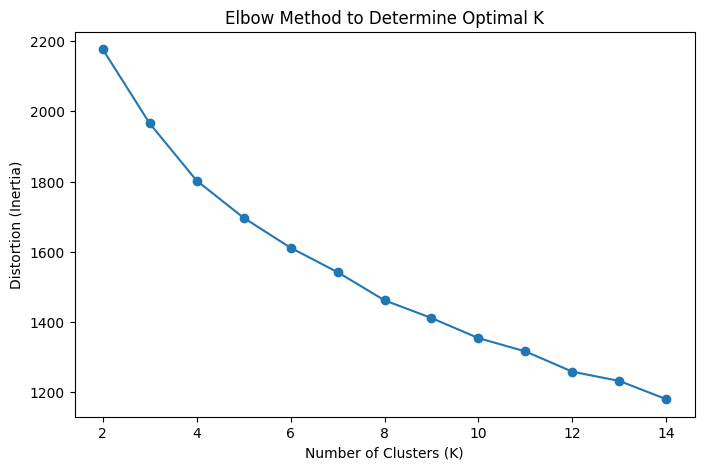

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def find_best_k(vectors, max_k=15):
    """Uses the Elbow Method to find the best K for clustering."""
    distortions = []
    
    for k in range(2, max_k):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(vectors)
        distortions.append(km.inertia_)  # Measure cluster cohesion

    # Plot elbow curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(2, max_k), distortions, marker='o', linestyle='-')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Distortion (Inertia)')
    plt.title('Elbow Method to Determine Optimal K')
    plt.show()

# Run the elbow method
find_best_k(business_vectors)

In [11]:
from kneed import KneeLocator

# List of K values (from 2 to max_k used in the plot)
k_values = list(range(2, 15))

# Compute distortion scores again
distortions = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(business_vectors)
    distortions.append(km.inertia_)

# Find the best K using the KneeLocator
knee_locator = KneeLocator(k_values, distortions, curve="convex", direction="decreasing")
best_k = knee_locator.elbow

print(f" Best K determined by KneeLocator: {best_k}")

 Best K determined by KneeLocator: 6


Cluster 0: ['39 North Taproom & Grill', 'La Sponda', 'World of Beer', 'The Twisted Tail', 'Locust Lane Craft Brewery']...
Cluster 1: ['Tuna Bar', 'BAP', 'Golden Chopstick Chinese Restaurant', 'Jong Ka Jib', 'The Royal Indian Cuisine']...
Cluster 2: ['Craft Hall', 'Bagelicious - King Of Prussia', 'Baltic Bakery', 'Brown Sugar Bakery & Cafe', 'Federal Donuts']...
Cluster 3: ['St Honore Pastries', 'Perkiomen Valley Brewery', 'Wawa', 'ReAnimator Coffee', 'Red Hook Coffee & Tea']...
Cluster 4: ['Ardmore Pizza', 'Core de Roma', 'Trattoria Totaro', 'Lucianis Pizzeria & GRILL', 'Minas Pizza']...
Cluster 5: ['The Love', 'Ryan Christopher', 'Metro Diner', 'La Cucina Italian Eatery', "Nudy's Cafe - Chadds Ford"]...


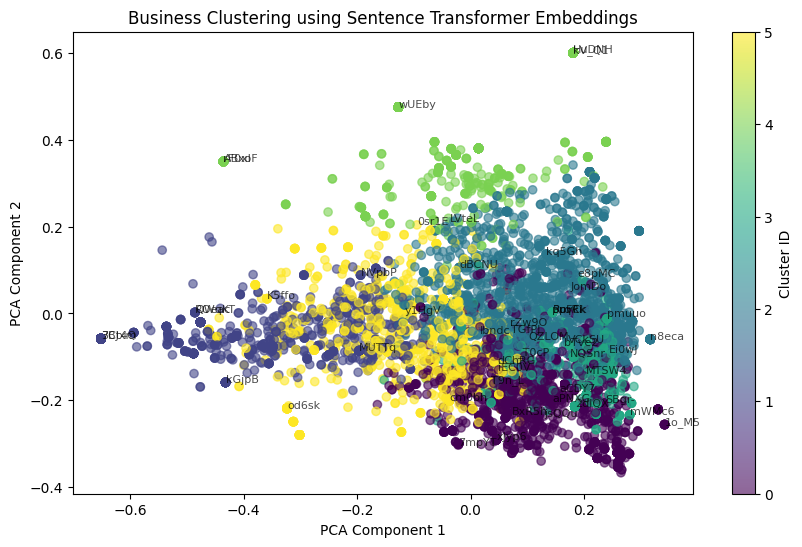

In [20]:
from sklearn.decomposition import PCA

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
business_data_path = os.path.join(BASE_DIR, "output_categories", "business_category_1.json")

# Choose K based on knee_locator
optimal_k = 6

# Run K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(business_vectors)

# Save cluster results
np.save("business_clusters.npy", clusters)

# Create a mapping from business_id to business name
business_id_to_name = {b["business_id"]: b["name"] for b in business_data}

# Store business names in clusters instead of IDs
business_clusters = {i: [] for i in range(optimal_k)}

for i, business_id in enumerate(business_ids):
    business_name = business_id_to_name.get(business_id, f"Unknown ({business_id})")  # Use name if available
    business_clusters[clusters[i]].append(business_name)  # Append name instead of ID

# Print first 5 business names per cluster
for cluster, biz_list in business_clusters.items():
    print(f"Cluster {cluster}: {biz_list[:5]}...")  # Print first 5 businesses per cluster

# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
business_vectors_2D = pca.fit_transform(business_vectors)

# Plot clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(business_vectors_2D[:, 0], business_vectors_2D[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(label="Cluster ID")

# Add labels for selected points
for i, business_id in enumerate(business_ids[:50]):  # Label first 50 businesses
    plt.text(business_vectors_2D[i, 0], business_vectors_2D[i, 1], business_id[:5], fontsize=8, alpha=0.7)

plt.title("Business Clustering using Sentence Transformer Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [21]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(business_vectors, clusters)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.16458144783973694


Cluster Categories Based on Business Co-Occurrence

Step 1: Build a Category Co-Occurrence Matrix. Count how many businesses share multiple categories.
If "Vegan" and "Vegetarian" appear in the same business frequently, their connection strengthens.

Step 2: Apply PCA and K-Means on the Co-Occurrence Matrix
Use PCA to reduce dimensionality.
Apply K-Means to find clusters.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Set paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
business_data_path = os.path.join(BASE_DIR, "output_categories", "business_category_1.json")
unique_categories_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories_2.json")

# Load unique categories
with open(unique_categories_path, "r", encoding="utf-8") as f:
    unique_categories = json.load(f)  # List of unique categories

# Load business-category data
with open(business_data_path, "r", encoding="utf-8") as f:
    business_data = json.load(f)

# Step 1: Build a Category Co-Occurrence Matrix
category_index = {cat: i for i, cat in enumerate(unique_categories)}
co_occurrence_matrix = np.zeros((len(unique_categories), len(unique_categories)))

for business in business_data:
    categories = business["categories"]
    category_ids = [category_index[cat] for cat in categories if cat in category_index]

    # Update co-occurrence counts
    for i in category_ids:
        for j in category_ids:
            if i != j:
                co_occurrence_matrix[i, j] += 1

# Normalize the matrix
co_occurrence_matrix = co_occurrence_matrix / co_occurrence_matrix.max()

# Step 2: Reduce Dimensionality with PCA
pca = PCA(n_components=10)  # Reduce to 10 dimensions for clustering
category_vectors = pca.fit_transform(co_occurrence_matrix)

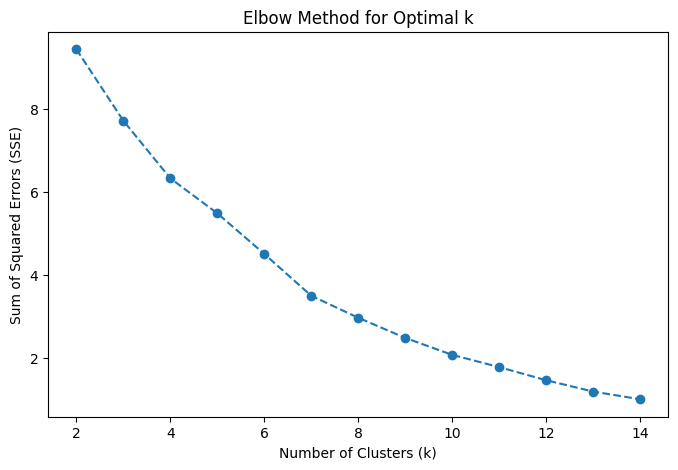

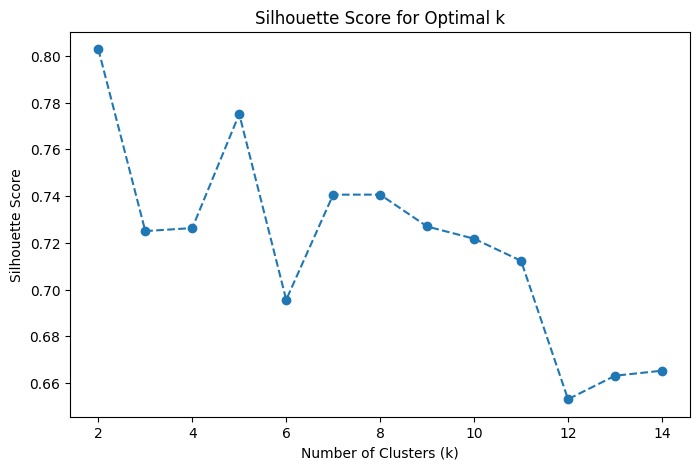

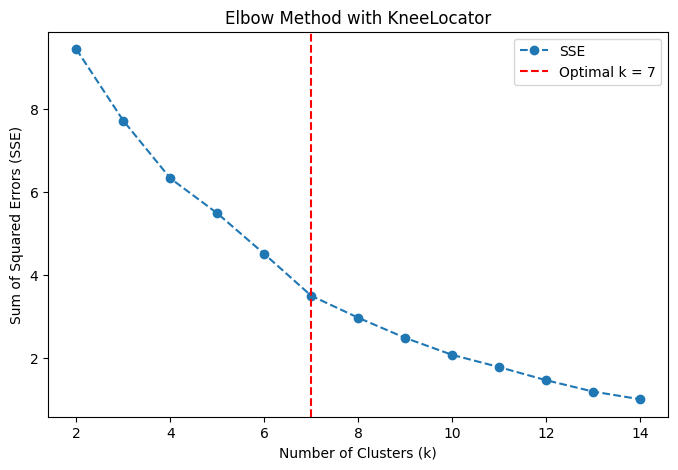

In [26]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Run K-Means for different values of k
sse = []
k_values = range(2, 15)  # Test different k values

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(category_vectors)  # category_vectors is the PCA-reduced category matrix
    sse.append(kmeans.inertia_)  # Inertia is the SSE (sum of squared errors)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, marker="o", linestyle="--")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal k")
plt.show()

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 15):  # Try different k values
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(category_vectors)
    score = silhouette_score(category_vectors, cluster_labels)  # Compute silhouette score
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 15), silhouette_scores, marker="o", linestyle="--")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.show()


from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Run K-Means for different values of k
sse = []
k_values = range(2, 15)  # Testing k from 2 to 14

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(category_vectors)  # category_vectors is the category embedding matrix
    sse.append(kmeans.inertia_)  # Inertia (SSE)

# Use KneeLocator to automatically find the best k
knee_locator = KneeLocator(k_values, sse, curve="convex", direction="decreasing")
optimal_k = knee_locator.elbow  # Get the best k

# Plot Elbow Method with the detected elbow
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, marker="o", linestyle="--", label="SSE")
plt.axvline(x=optimal_k, linestyle="--", color="red", label=f"Optimal k = {optimal_k}")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method with KneeLocator")
plt.legend()
plt.show()

Elbow: 6, 7
Silhoutte: 2, 5, 7
Kneed: 7

Clustered categories saved to: d:\Programming\LLM_RS\output_categories\category_clusters_kMeans.json
Cluster 0: ['Acai Bowls', 'Afghan', 'African', 'Arabic', 'Argentine']...
Cluster 1: ['American (New)', 'American (Traditional)']...
Cluster 2: ['Bakeries', 'Breakfast & Brunch', 'Burgers', 'Cafes', 'Caterers']...
Cluster 3: ['Bars']...
Cluster 4: ['Pizza']...
Cluster 5: ['Beer', 'Beer Bar', 'Cocktail Bars', 'Gastropubs', 'Pubs']...
Cluster 6: ['Italian', 'Sandwiches']...


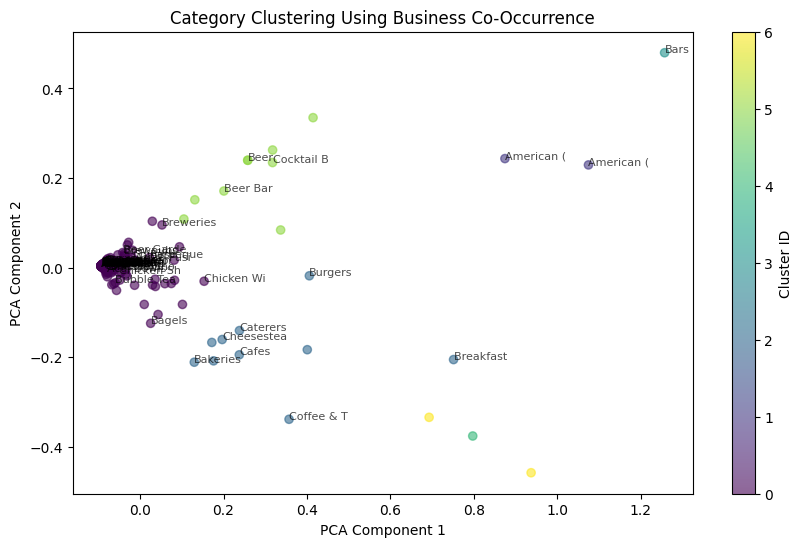

Clusters saved to d:\Programming\LLM_RS\output_categories\category_clusters_kMeans.json.


In [29]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Set file path to save cluster results
cluster_output_path = os.path.join(BASE_DIR, "output_categories", "category_clusters_kMeans.json")

# Step 3: Apply K-Means Clustering
optimal_k = 7  # Adjust based on elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
category_clusters = kmeans.fit_predict(category_vectors)

# Step 4: Map Categories to Clusters
clustered_categories = {i: [] for i in range(optimal_k)}

for i, category in enumerate(unique_categories):
    clustered_categories[category_clusters[i]].append(category)

# Save clusters to JSON file
with open(cluster_output_path, "w", encoding="utf-8") as f:
    json.dump(clustered_categories, f, indent=2, ensure_ascii=False)

print(f"Clustered categories saved to: {cluster_output_path}")

# Print sample cluster output
for cluster, cat_list in clustered_categories.items():
    print(f"Cluster {cluster}: {cat_list[:5]}...")  # Show first 5 per cluster

# Step 5: Visualize Clusters in 2D
pca_2d = PCA(n_components=2)
category_vectors_2D = pca_2d.fit_transform(category_vectors)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(category_vectors_2D[:, 0], category_vectors_2D[:, 1], c=category_clusters, cmap='viridis', alpha=0.6)
plt.colorbar(label="Cluster ID")

# Add text labels for selected categories
for i, category in enumerate(unique_categories[:50]):  # Label first 50 for readability
    plt.text(category_vectors_2D[i, 0], category_vectors_2D[i, 1], category[:10], fontsize=8, alpha=0.7)

plt.title("Category Clustering Using Business Co-Occurrence")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

print(f"Clusters saved to {cluster_output_path}.")

Hierarchical Clustering

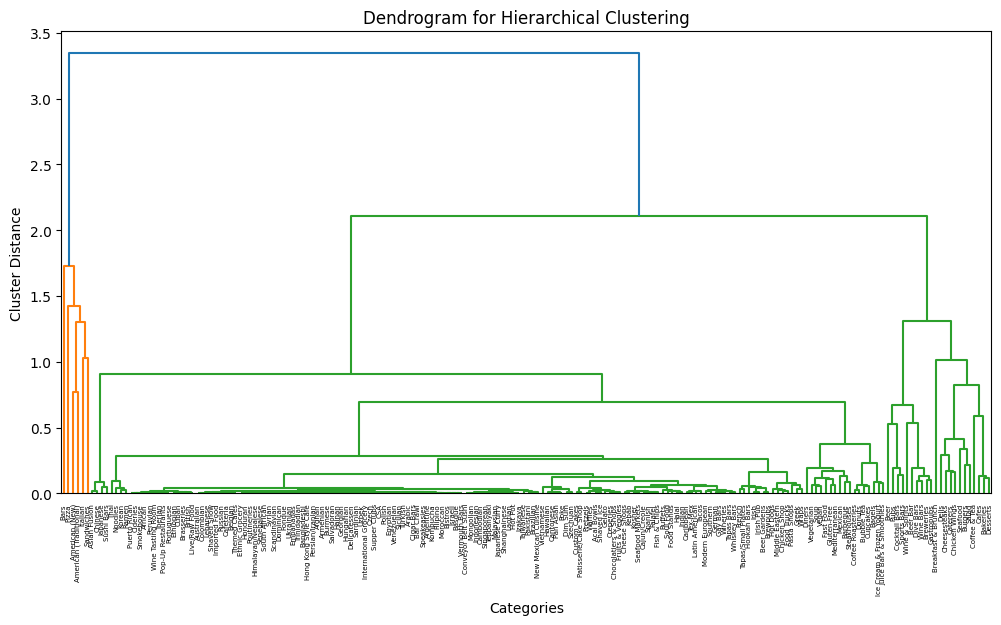

Hierarchical clustered categories saved to: d:\Programming\LLM_RS\output_categories\category_clusters_hierarchical.json


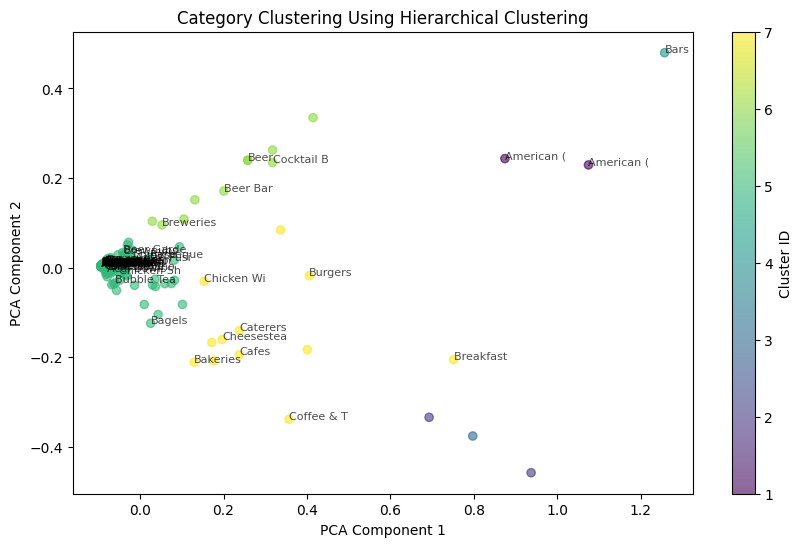

In [30]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA

# Set file path to save hierarchical clusters
cluster_output_path = os.path.join(BASE_DIR, "output_categories", "category_clusters_hierarchical.json")

# Step 1: Compute Hierarchical Clustering
linked = linkage(category_vectors, method='ward')  # "ward" minimizes variance within clusters

# Step 2: Plot the Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=unique_categories, leaf_rotation=90)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Categories")
plt.ylabel("Cluster Distance")
plt.show()

# Step 3: Choose Number of Clusters (`k`) Based on the Dendrogram
optimal_k = 7  # Adjust based on dendrogram structure
category_clusters = fcluster(linked, optimal_k, criterion='maxclust')  # Cuts tree at `k=7`

# Step 4: Map Categories to Clusters
clustered_categories = {i: [] for i in range(1, optimal_k + 1)}

for i, category in enumerate(unique_categories):
    clustered_categories[category_clusters[i]].append(category)

# Save hierarchical clusters to JSON file
with open(cluster_output_path, "w", encoding="utf-8") as f:
    json.dump(clustered_categories, f, indent=2, ensure_ascii=False)

print(f"Hierarchical clustered categories saved to: {cluster_output_path}")

# Step 5: Reduce to 2D using PCA for visualization
pca_2d = PCA(n_components=2)
category_vectors_2D = pca_2d.fit_transform(category_vectors)

# Plot clusters (color by hierarchical cluster assignments)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(category_vectors_2D[:, 0], category_vectors_2D[:, 1], c=category_clusters, cmap='viridis', alpha=0.6)
plt.colorbar(label="Cluster ID")

# Add text labels for selected categories
for i, category in enumerate(unique_categories[:50]):  # Label first 50 for readability
    plt.text(category_vectors_2D[i, 0], category_vectors_2D[i, 1], category[:10], fontsize=8, alpha=0.7)

plt.title("Category Clustering Using Hierarchical Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [32]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans

# Step 1: Run K-Means first
optimal_k = 12
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
first_level_clusters = kmeans.fit_predict(category_vectors)

# Step 2: Find large clusters and apply Hierarchical Clustering
max_cluster_size = 30  # If a cluster has more than this, refine it
final_clusters = {}

for cluster_id in range(optimal_k):
    cluster_indices = np.where(first_level_clusters == cluster_id)[0]
    
    if len(cluster_indices) > max_cluster_size:
        print(f"Refining Cluster {cluster_id} with {len(cluster_indices)} categories...")

        # Extract only those categories
        sub_vectors = category_vectors[cluster_indices]
        linked = linkage(sub_vectors, method="ward")
        refined_labels = fcluster(linked, 6, criterion="maxclust")  # Choose a new `k` dynamically
        
        # Map refined clusters
        for i, idx in enumerate(cluster_indices):
            final_clusters[idx] = f"Cluster {cluster_id}.{refined_labels[i]}"  # Hierarchical sub-cluster
    else:
        for idx in cluster_indices:
            final_clusters[idx] = f"Cluster {cluster_id}"  # Keep original cluster

# Map category names to clusters
category_cluster_map = {unique_categories[i]: final_clusters[i] for i in range(len(unique_categories))}

# Save refined clusters
cluster_output_path = os.path.join(BASE_DIR, "output_categories", "category_clusters_KMeansHierarchy.json")
with open(cluster_output_path, "w", encoding="utf-8") as f:
    json.dump(category_cluster_map, f, indent=2, ensure_ascii=False)

print(f"Clusters saved to {cluster_output_path}.")


Refining Cluster 0 with 148 categories...
Clusters saved to d:\Programming\LLM_RS\output_categories\category_clusters_KMeansHierarchy.json.


Hybrid: semantic + co-occurrence

Computing semantic embeddings...
Loading co-occurrence matrix...
Reducing dimensions with PCA...
Combining semantic and co-occurrence features...
Performing Hierarchical Clustering...


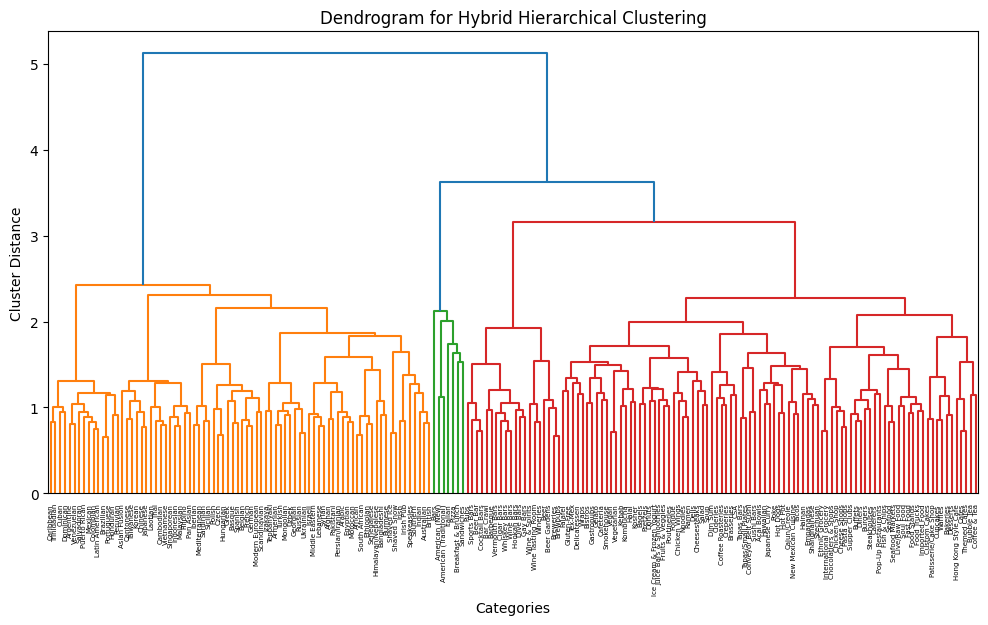

In [33]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# Set paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
unique_categories_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories_2.json")
business_data_path = os.path.join(BASE_DIR, "output_categories", "business_category_1.json")

# Load unique restaurant categories
with open(unique_categories_path, "r", encoding="utf-8") as f:
    unique_categories = json.load(f)

# Load business-category data
with open(business_data_path, "r", encoding="utf-8") as f:
    business_data = json.load(f)

# Step 1: Compute Sentence Embeddings for Categories (Semantic Information)
print("Computing semantic embeddings...")
model = SentenceTransformer('all-MiniLM-L6-v2')
semantic_vectors = np.array([model.encode(cat) for cat in unique_categories])

# Step 2: Load Precomputed Co-Occurrence Matrix
print("Loading co-occurrence matrix...")
category_index = {cat: i for i, cat in enumerate(unique_categories)}
co_occurrence_matrix = np.zeros((len(unique_categories), len(unique_categories)))

for business in business_data:
    categories = business["categories"]
    category_ids = [category_index[cat] for cat in categories if cat in category_index]

    # Update co-occurrence counts
    for i in category_ids:
        for j in category_ids:
            if i != j:
                co_occurrence_matrix[i, j] += 1

# Normalize co-occurrence values
co_occurrence_matrix = co_occurrence_matrix / co_occurrence_matrix.max()

# Step 3: Reduce Dimensionality with PCA
print("Reducing dimensions with PCA...")
pca = PCA(n_components=10)
co_occurrence_vectors = pca.fit_transform(co_occurrence_matrix)

# Step 4: Combine Semantic Embeddings + Co-Occurrence Features
print("Combining semantic and co-occurrence features...")
combined_vectors = np.hstack((semantic_vectors, co_occurrence_vectors))

# Step 5: Perform Hierarchical Clustering
print("Performing Hierarchical Clustering...")
linked = linkage(combined_vectors, method='ward')

# Step 6: Plot the Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=unique_categories, leaf_rotation=90)
plt.title("Dendrogram for Hybrid Hierarchical Clustering")
plt.xlabel("Categories")
plt.ylabel("Cluster Distance")
plt.show()

distance_threshold = 2.0
5~7 Clusters

In [34]:
# Step 7: Choose Number of Clusters (`k`) Based on Dendrogram
optimal_k = 7  # Adjust based on dendrogram visualization
category_clusters = fcluster(linked, optimal_k, criterion='maxclust')

# Step 8: Map Categories to Clusters
clustered_categories = {i: [] for i in range(1, optimal_k + 1)}

for i, category in enumerate(unique_categories):
    clustered_categories[category_clusters[i]].append(category)

# Step 9: Save Clustered Categories to JSON
cluster_output_path = os.path.join(BASE_DIR, "output_categories", "category_clusters_hybrid.json")

with open(cluster_output_path, "w", encoding="utf-8") as f:
    json.dump(clustered_categories, f, indent=2, ensure_ascii=False)

print(f"Hybrid hierarchical clustered categories saved to: {cluster_output_path}")

Hybrid hierarchical clustered categories saved to: d:\Programming\LLM_RS\output_categories\category_clusters_hybrid.json


//Quit
T5 to identify highly related businesses (exclude grocery, supermarket, etc.)
- Uses GPU acceleration (torch.cuda)
- Processes in batches for efficiency
- Uses Hugging Face's datasets for streaming (so it won’t crash with large data)
- Uses optimized prompt structure for higher accuracy

In [48]:
import os
import json
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset  # Hugging Face's datasets library for streaming

# Set up paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_filtered_dining_businesses.json")
filtered_output_path = os.path.join(BASE_DIR, "output_businesses", "pa_t5_filtered_dining.json")

# Load T5 model (Use flan-t5-base for better accuracy)
model_name = "google/flan-t5-small"  # Change to "flan-t5-base" for better classification
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")

# Optimized classification prompt
PROMPT_TEMPLATE = """Determine whether the following business is a dining establishment (such as a restaurant, café, or bistro) or a retail store (such as a grocery store, department store, or shopping mall). 
Answer 'YES' if it is a dining establishment and 'NO' otherwise.

Business Name: {name}
Categories: {categories}
"""

# Function to classify businesses using T5 in batches
def classify_business(businesses):
    relevant_businesses = []
    batch_texts = []

    for business in businesses:
        name = business.get("name", "Unknown")
        categories = business.get("categories", "No category")

        # Construct input prompt
        prompt = PROMPT_TEMPLATE.format(name=name, categories=categories)

        batch_texts.append((business, prompt))  # Store business and prompt

    # Process batch with T5
    inputs = tokenizer([p[1] for p in batch_texts], return_tensors="pt", padding=True, truncation=True).to(model.device)
    outputs = model.generate(**inputs, max_length=5)  # Generate output
    responses = tokenizer.batch_decode(outputs, skip_special_tokens=True)

    # Filter relevant businesses
    for idx, response in enumerate(responses):
        if "yes" in response.lower():
            relevant_businesses.append(batch_texts[idx][0])  # Append original business data

    return relevant_businesses

# Use Hugging Face's datasets to stream data (prevents memory issues)
dataset = load_dataset("json", data_files=input_path, split="train", streaming=True)

# Process in batches (batch size = 50 for speed)
BATCH_SIZE = 50
filtered_businesses = []
batch = []

for business in dataset:
    batch.append(business)
    if len(batch) >= BATCH_SIZE:
        filtered_businesses.extend(classify_business(batch))
        batch = []  # Reset batch

# Process remaining batch
if batch:
    filtered_businesses.extend(classify_business(batch))

# Save filtered results
with open(filtered_output_path, "w", encoding="utf-8") as f:
    json.dump(filtered_businesses, f, indent=2, ensure_ascii=False)

print(f"Filtering complete: {len(filtered_businesses)} businesses saved to {filtered_output_path}.")


Filtering complete: 6845 businesses saved to d:\Programming\LLM_RS\output_businesses\pa_t5_filtered_dining.json.


Determine a Minimum Frequency Threshold (Rare Category Analysis)

We have 7209 businesses in total, 类别出现频率的阈值，常见做法是基于总餐厅数的 0.5%~2%, 即36 frequencies以上

50%–70% retention often balances coverage & noise reduction.

In [37]:
# Threshold Analysis with Percentage
thresholds = [1, 2, 5, 6, 7, 10, 20, 36, 50, 100]  # Define thresholds
total_categories = len(sorted_categories)  # Total number of categories

for t in thresholds:
    kept = sum(1 for _, count in sorted_categories.items() if count >= t)
    percentage = (kept / total_categories) * 100  # Calculate percentage
    print(f"Threshold {t}: {kept}/{total_categories} categories kept ({percentage:.2f}%)")

Threshold 1: 195/195 categories kept (100.00%)
Threshold 2: 178/195 categories kept (91.28%)
Threshold 5: 146/195 categories kept (74.87%)
Threshold 6: 142/195 categories kept (72.82%)
Threshold 7: 131/195 categories kept (67.18%)
Threshold 10: 117/195 categories kept (60.00%)
Threshold 20: 99/195 categories kept (50.77%)
Threshold 36: 78/195 categories kept (40.00%)
Threshold 50: 69/195 categories kept (35.38%)
Threshold 100: 47/195 categories kept (24.10%)


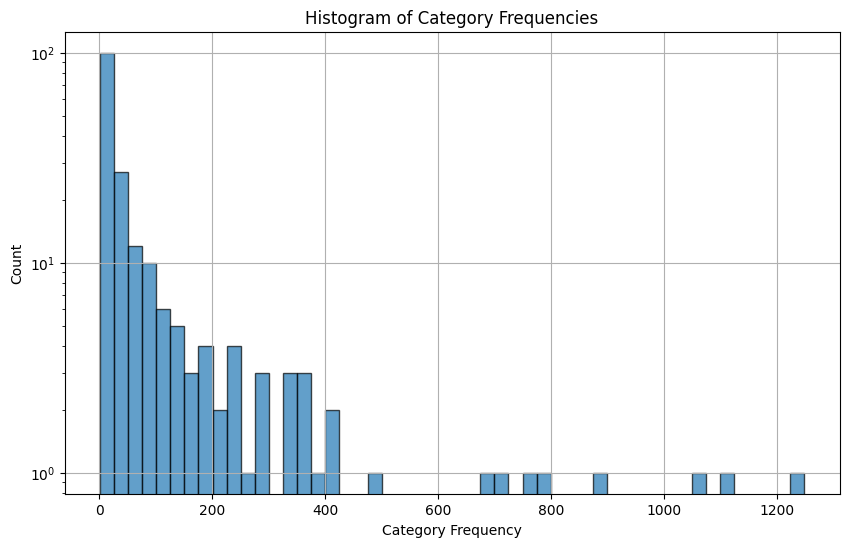

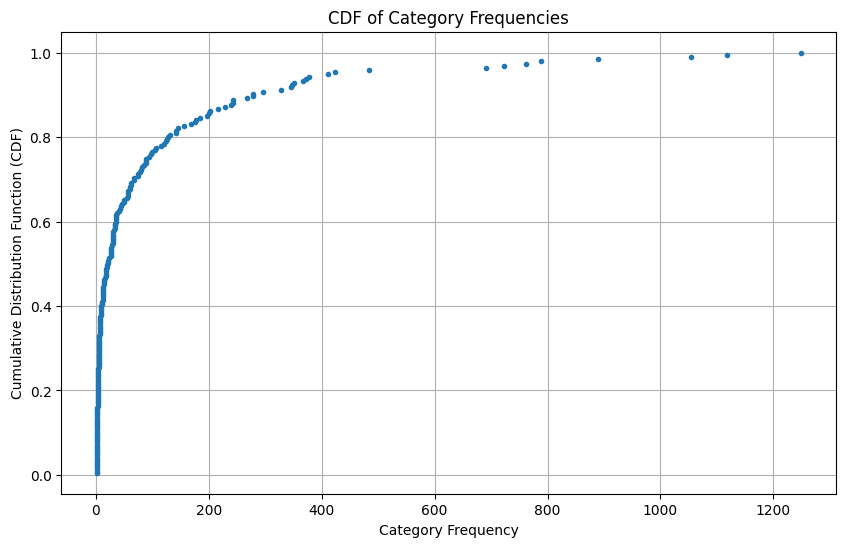

In [34]:
import json
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
freq_output_path = os.path.join(BASE_DIR, "output_categories", "pa_category_frequencies.json")

with open(freq_output_path, 'r', encoding='utf-8') as f:
    sorted_categories = json.load(f)

frequencies = list(sorted_categories.values())

plt.figure(figsize=(10, 6))
plt.hist(frequencies, bins=50, alpha=0.7, edgecolor="black")
plt.xlabel("Category Frequency")
plt.ylabel("Count")
plt.title("Histogram of Category Frequencies")
plt.yscale("log") 
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sorted_freqs = np.sort(frequencies)
cdf = np.arange(1, len(sorted_freqs) + 1) / len(sorted_freqs)
plt.plot(sorted_freqs, cdf, marker=".", linestyle="none")
plt.xlabel("Category Frequency")
plt.ylabel("Cumulative Distribution Function (CDF)")
plt.title("CDF of Category Frequencies")
plt.grid(True)
plt.show()


In [ ]:
import json
import os

# Set base directory and file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_categories", "pa_unique_categories.json")
output_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories.json")

# Ensure the output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Load unique categories
with open(input_path, 'r', encoding='utf-8') as f:
    unique_categories = json.load(f)

initial_count = len(unique_categories)
print(f"Initial unique categories: {initial_count}")

# Define categories to remove (Non-food-related & Overly broad)
irrelevant_categories = {
    "Accessories", "Accountants", "Active Life", "Acupuncture", "Adult", "Adult Education", "Adult Entertainment",
    "Airlines", "Airport Lounges", "Airports", "Amusement Parks", "Antiques", "Apartments", "Appliances",
    "Appliances & Repair", "Arcades", "Art Classes", "Art Galleries", "Art Museums", "Art Schools", "Arts & Crafts",
    "Arts & Entertainment", "Attraction Farms", "Auto Glass Services", "Auto Repair", "Automotive", "Axe Throwing",
    "Baby Gear & Furniture", "Banks & Credit Unions", "Barbers", "Barre Classes", "Bartenders", "Bartending Schools",
    "Beaches", "Beauty & Spas", "Bed & Breakfast", "Bike Rentals", "Bike Repair/Maintenance", "Bike Tours", "Bikes",
    "Boat Charters", "Boat Tours", "Boating", "Body Contouring", "Books", "Bookstores", "Botanical Gardens",
    "Bowling", "Bridal", "Business Consulting", "Candle Stores", "Cannabis Clinics", "Cannabis Dispensaries",
    "Cardio Classes", "Cards & Stationery", "Casinos", "Check Cashing/Pay-day Loans", "Children's Clothing",
    "Christmas Trees", "Cinema", "Colleges & Universities", "Colonics", "Comedy Clubs", "Comic Books",
    "Community Service/Non-Profit", "Convenience Stores", "Cooking Classes", "Cooking Schools",
    "Cosmetics & Beauty Supply", "Costumes", "Country Clubs", "Couriers & Delivery Services", "Cultural Center",
    "Dance Clubs", "Day Camps", "Day Spas", "Dentists", "Department Stores", "Dinner Theater", "Discount Store",
    "Distilleries", "Doctors", "Drugstores", "Dry Cleaning", "Dry Cleaning & Laundry", "Education",
    "Educational Services", "Electronics", "Event Planning & Services", "Eyewear & Opticians", "Farmers Market",
    "Fashion", "Festivals", "Financial Advising", "Financial Services", "Fireplace Services", "Fitness & Instruction",
    "Fitness/Exercise Equipment", "Flea Markets", "Floral Designers", "Florists", "Flowers & Gifts", "Furniture Stores",
    "Gas Stations", "General Dentistry", "Gift Shops", "Golf", "Golf Lessons", "Gyms", "Hair Salons", "Hair Stylists",
    "Head Shops", "Health & Medical", "Health Markets", "Herbal Shops", "Herbs & Spices", "Hiking",
    "Historical Tours", "Hobby Shops", "Home & Garden", "Home Decor", "Home Services", "Hotels", "Hotels & Travel",
    "Indoor Playcentre", "Internet Cafes", "Jewelry", "Kids Activities", "Kitchen & Bath", "Kitchen Supplies",
    "LAN Centers", "Landmarks & Historical Buildings", "Laundromat", "Laundry Services", "Lawyers", "Libraries",
    "Local Flavor", "Local Services", "Macarons", "Mags", "Marketing", "Mass Media", "Massage", "Massage Therapy",
    "Medical Spas", "Men's Clothing", "Mini Golf", "Mountain Biking", "Museums", "Music & DVDs", "Music & Video",
    "Music Venues", "Nail Salons", "Nail Technicians", "Naturopathic/Holistic", "Newspapers & Magazines",
    "Nightlife", "Nurseries & Gardening", "Nutritionists", "Office Equipment", "Olive Oil", "Organic Stores",
    "Outdoor Furniture Stores", "Outlet Stores", "Paint & Sip", "Parenting Classes", "Parks",
    "Party & Event Planning", "Party Equipment Rentals", "Party Supplies", "Performing Arts", "Personal Chefs",
    "Personal Shopping", "Pet Adoption", "Pet Groomers", "Pet Services", "Pet Stores", "Pet Training", "Pets",
    "Photography Stores & Services", "Physical Therapy", "Pilates", "Playgrounds", "Pool & Billiards", "Pool Halls",
    "Print Media", "Private Tutors", "Professional Services", "Public Markets", "Public Services & Government",
    "Real Estate", "Recreation Centers", "Recycling Center", "Reflexology", "Religious Organizations", "Resorts",
    "Rest Stops", "Retail", "Salon", "Saunas", "Shopping", "Shopping Centers", "Shoe Stores", "Skating Rinks",
    "Skin Care", "Social Clubs", "Souvenir Shops", "Special Education", "Specialty Schools", "Spiritual Shop",
    "Sporting Goods", "Sports Clubs", "Sports Wear", "Strip Clubs", "Summer Camps", "Swimming Pools",
    "Tabletop Games", "Tableware", "Tasting Classes", "Tea Rooms", "Team Building Activities", "Tennis",
    "Thrift Stores", "Ticket Sales", "Tiki Bars", "Tires", "Tobacco Shops", "Tours", "Toy Stores",
    "Traditional Chinese Medicine", "Trainers", "Transportation", "Travel Services", "Tutoring Centers",
    "Used", "Vape Shops", "Venues & Event Spaces", "Veterinarians", "Videos & Video Game Rental",
    "Vintage & Consignment", "Vinyl Records", "Visitor Centers", "Vitamins & Supplements", "Walking Tours",
    "Watches", "Wedding Planning", "Weight Loss Centers", "Wheel & Rim Repair", "Wholesale Stores", "Wholesalers",
    "Wigs", "Women's Clothing", "Yoga", "Zoos", "Unofficial Yelp Events", "Yelp Events", "Pumpkin Patches", "Guest Houses", "Preschools",
    "Restaurant Supplies", "Pharmacy", "Hospitals", "Hostels", "Pick Your Own Farms","Bike Tours","Bike tours"
    "Bus Tours",
    "Food Tours",
    "Jazz & Blues",
    "Karaoke",
    "Lounges","Meat Shops"
}

# Define overly broad food categories to remove
overly_broad_categories = {
    "Food", "Restaurants", "Grocery", "Specialty Food", "Ethnic Food", "Comfort Food",
    "Do-It-Yourself Food",
    "Eatertainment",
    "Food Court",
    "Food Delivery Services",
}

# Remove only the defined categories (no merging)
filtered_categories = {
    c for c in unique_categories if c not in irrelevant_categories and c not in overly_broad_categories
}

# Save cleaned categories
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(sorted(filtered_categories), f, indent=2, ensure_ascii=False)

# Print final stats
final_count = len(filtered_categories)
removed_count = initial_count - final_count
print(f"Initial unique categories: {initial_count}")
print(f"Number of removed categories: {removed_count}")
print(f"Final cleaned categories count: {final_count}")
print(f"Filtered categories saved to: {output_path}")

Initial unique categories: 484


AttributeError: 'list' object has no attribute 'items'

Remain some catregories to be removed

1. Automatically match keywords and merge similar categories (e.g., "Bars", "Gay Bars", "Beer Bar" → "Bars").
2. Remove remaining irrelevant categories.

In [3]:
import json
import os

# Set base directory and file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_categories", "pa_cleaned_categories.json")
output_path = os.path.join(BASE_DIR, "output_categories", "pa_refined_categories.json")

# Ensure the output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Load cleaned categories
with open(input_path, 'r', encoding='utf-8') as f:
    cleaned_categories = json.load(f)

initial_count = len(cleaned_categories)

# Categories to remove (still irrelevant)
irrelevant_categories = {
    "Unofficial Yelp Events", "Yelp Events", "Pumpkin Patches", "Guest Houses", "Preschools",
    "Restaurant Supplies", "Pharmacy", "Hospitals", "Hostels", "Pick Your Own Farms"
}

# Auto-merging rules: Keywords -> Merged category
keyword_merges = {
    "bar": "Bars",
    "beer": "Bars",
    "wine": "Wine & Spirits",
    "coffee": "Coffee",
    "tea": "Tea-Based Drinks",
    "juice": "Healthy Drinks",
    "smoothie": "Healthy Drinks",
    "cocktail": "Bars",
    "pub": "Bars",
    "brew": "Bars",
    "poke": "Hawaiian",
    "sushi": "Japanese",
    "ramen": "Japanese",
    "noodle": "Asian Fusion",
    "pasta": "Italian",
    "pizza": "Italian",
    "steak": "Steak",
    "bbq": "Barbecue",
    "dim sum": "Chinese",
    "tapas": "Spanish",
    "sandwich": "Delis",
    "donut": "Desserts",
    "bakery": "Desserts",
    "gelato": "Desserts",
    "ice cream": "Desserts",
    "fast food": "Quick Service",
    "food truck": "Quick Service",
    "vegan": "Vegan & Vegetarian",
    "vegetarian": "Vegan & Vegetarian",
}

# Process categories
processed_categories = set()

for category in cleaned_categories:
    if category in irrelevant_categories:
        continue
    
    # Apply keyword merging
    merged_category = None
    for keyword, target in keyword_merges.items():
        if keyword in category.lower():
            merged_category = target
            break
    
    processed_categories.add(merged_category if merged_category else category)

# Convert to sorted list
final_categories = sorted(processed_categories)

# Save final cleaned categories
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(final_categories, f, indent=2, ensure_ascii=False)

# Print final stats
final_count = len(final_categories)
removed_count = initial_count - final_count

print(f"Initial categories count: {initial_count}")
print(f"Number of removed categories: {removed_count}")
print(f"Final categories count: {final_count}")
print(f"Final cleaned categories saved to: {output_path}")


Initial categories count: 208
Number of removed categories: 41
Final categories count: 167
Final cleaned categories saved to: d:\Programming\LLM_RS\output_categories\pa_refined_categories.json


1. Maps them into structured groups (Cuisine, Food Type, Service Type, Dietary, etc.).
2. Removes irrelevant categories.
3. Outputs a cleaned category list in JSON format

Or: try Clustering
(TODO)

## 2. attributes

In [9]:
import json
import os
from collections import defaultdict, Counter

# Set base directory and file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_filtered_dining_businesses.json")
output_path = os.path.join(BASE_DIR, "output_attributes", "attribute_analysis.json")  # Changed path

# Load businesses
with open(input_path, 'r', encoding='utf-8') as f:
    businesses = json.load(f)

# Extract attributes
attribute_counts = Counter()
attribute_values = defaultdict(set)

for business in businesses:
    attributes = business.get('attributes', {})  # Ensure attributes is a dictionary
    if not isinstance(attributes, dict):  # Handle cases where attributes is None or another type
        continue

    for attr, value in attributes.items():
        attribute_counts[attr] += 1  # Count occurrences
        attribute_values[attr].add(value)  # Track unique values

# Sort attributes by frequency
sorted_attributes = sorted(attribute_counts.items(), key=lambda x: x[1], reverse=True)

# Display top attributes
print("Top Business Attributes by Frequency:")
for attr, count in sorted_attributes[:20]:  # Show top 20 attributes
    print(f"{attr}: {count} businesses")

# Save the extracted attributes and values for deeper analysis
with open(output_path, "w", encoding="utf-8") as f:
    json.dump({"counts": attribute_counts, "values": {k: list(v) for k, v in attribute_values.items()}}, f, indent=2)

print(f"\nExtracted attributes saved to: {output_path}")


Top Business Attributes by Frequency:
RestaurantsTakeOut: 6734 businesses
BusinessAcceptsCreditCards: 6682 businesses
BusinessParking: 6678 businesses
RestaurantsDelivery: 6348 businesses
RestaurantsPriceRange2: 6113 businesses
BikeParking: 5752 businesses
OutdoorSeating: 5536 businesses
HasTV: 5307 businesses
WiFi: 5288 businesses
Ambience: 5261 businesses
RestaurantsReservations: 5209 businesses
Alcohol: 5123 businesses
Caters: 5087 businesses
RestaurantsGoodForGroups: 4905 businesses
GoodForKids: 4782 businesses
NoiseLevel: 4544 businesses
RestaurantsAttire: 4455 businesses
GoodForMeal: 4062 businesses
RestaurantsTableService: 2781 businesses
WheelchairAccessible: 2378 businesses

Extracted attributes saved to: d:\Programming\LLM_RS\output_attributes\attribute_analysis.json


Reduce dimensions:

Remove low-occurrence attributes (appear in <5% of businesses).

Group categories (e.g., some might be similar).

Normalize numerical values (e.g., review_count → log scale transformation).

Keep only decision-making features.

In [11]:
import json
import os
import ast
from collections import defaultdict

# Set base directory and file paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
input_path = os.path.join(BASE_DIR, "output_businesses", "pa_filtered_dining_businesses.json")
output_path = os.path.join(BASE_DIR, "output_attributes", "flattened_attribute.json")

# Load businesses
with open(input_path, 'r', encoding='utf-8') as f:
    businesses = json.load(f)

# Function to parse and normalize attribute values
def parse_value(value):
    """Convert string representations of dicts to actual dicts & normalize other values."""
    if isinstance(value, str):
        try:
            parsed_value = ast.literal_eval(value)  # Convert string to dictionary
            if isinstance(parsed_value, dict):
                return parsed_value
        except (ValueError, SyntaxError):
            pass  # Not a dictionary, keep as is
    return value  # Return raw value if not a dictionary

# Flattened attributes storage
flattened_attributes = defaultdict(set)

for business in businesses:
    attributes = business.get("attributes", {})
    if not isinstance(attributes, dict):  # Skip invalid attributes
        continue

    for attr, value in attributes.items():
        parsed_value = parse_value(value)  # Try to parse the value
        
        if isinstance(parsed_value, dict):  # Handle nested dictionaries
            for sub_attr, sub_value in parsed_value.items():
                if sub_value is None:
                    sub_value = "Unknown"  # Replace None with 'Unknown'
                elif isinstance(sub_value, bool):
                    sub_value = "True" if sub_value else "False"
                flattened_attributes[f"{attr}_{sub_attr}"].add(str(sub_value))
        else:
            # Normalize boolean and categorical values
            if parsed_value is None or parsed_value == "None":
                parsed_value = "Unknown"
            elif isinstance(parsed_value, bool):
                parsed_value = "True" if parsed_value else "False"
            elif isinstance(parsed_value, str):
                parsed_value = parsed_value.strip("u'")  # Remove Unicode markers
            
            flattened_attributes[attr].add(str(parsed_value))

# Convert sets to lists for JSON saving
cleaned_attributes = {k: list(v) for k, v in flattened_attributes.items() if v != {"Unknown"}}  # Remove all-"Unknown" attributes

# Save cleaned and structured attributes
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(cleaned_attributes, f, indent=2, ensure_ascii=False)

print(f"\nFinal cleaned attributes saved to: {output_path}")
print(f"Total unique attributes after final cleaning: {len(cleaned_attributes)}")



Final cleaned attributes saved to: d:\Programming\LLM_RS\output_attributes\flattened_attribute.json
Total unique attributes after final cleaning: 73
